In [22]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [23]:
# Read the traning and testing data set.

df_training = pd.read_csv('../Data/training_data.csv')
df_test = pd.read_csv('../Data/test_data.csv')

# Look at the dataframe.
df_training.head()

,measured_on,poa_global,temp_air,wind_speed_mph,actual_power_kw
0,2017-11-30 16:00:00-08:00,0.0,38.8,1.2,0.0
1,2017-11-30 16:15:00-08:00,0.0,38.8,1.2,0.0
2,2017-11-30 16:30:00-08:00,0.0,38.8,1.2,0.0
3,2017-11-30 16:45:00-08:00,0.0,38.8,1.2,0.0
4,2017-11-30 17:00:00-08:00,0.0,37.0,2.6,0.0


In [24]:
# ── 1. Setup ────────────────────────────────────────────────────
df = df_training.copy()
df['measured_on'] = pd.to_datetime(df['measured_on'], utc=True)
df = df.sort_values('measured_on').reset_index(drop=True)
df = df.set_index('measured_on')


We will use the LightGBM model(LGB) to do the prection. LightGBM has no built-in understanding of time. So we will create more features for a time-series prediction by using LighgGBM. LightGBM treats each rwo as independent - it has no memorey of previous rows. Lag features manually give the model access to past values, mimicking the 'memory'.

Solar power has strong daily and seasonal cycles — peak at noon, zero at night. We also use sin/cos features instead of raw hour numbers preserves the circular nature of time.

In [25]:
# ── 2. Feature engineering ──────────────────────────────────────
# Data is 15-min intervals, so lag 1 = 15 min ago, lag 4 = 1 hour ago
for col in ['poa_global', 'temp_air', 'wind_speed_mph']:
    df[f'{col}_lag1']      = df[col].shift(1)   # 15 min ago
    df[f'{col}_lag2']      = df[col].shift(2)   # 30 min ago
    df[f'{col}_lag4']      = df[col].shift(4)   # 1 hour ago

    # Captures the local trend and volatility over a short window, smoothing out noise
    # If irradiance has been consistently high for the past hour, power output is likely still high
    df[f'{col}_roll4_mean'] = df[col].shift(1).rolling(4).mean()   # 1-hour mean
    df[f'{col}_roll8_mean'] = df[col].shift(1).rolling(8).mean()   # 2-hour mean
    df[f'{col}_roll4_std']  = df[col].shift(1).rolling(4).std()    # 1-hour std


# Cyclical time features
df['hour_sin']   = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos']   = np.cos(2 * np.pi * df.index.hour / 24)
df['month_sin']  = np.sin(2 * np.pi * df.index.month / 12)
df['month_cos']  = np.cos(2 * np.pi * df.index.month / 12)
df['minute_sin'] = np.sin(2 * np.pi * df.index.minute / 60)
df['minute_cos'] = np.cos(2 * np.pi * df.index.minute / 60)

# A simple binary flag that tells the model night vs day — since solar power is always 0 at night, this is one of the most powerful features.
df['is_daytime'] = ((df.index.hour >= 6) & (df.index.hour <= 20)).astype(int)

df = df.dropna().reset_index()

In [26]:
# ── 3. Define target & features ─────────────────────────────────
target   = 'actual_power_kw'
features = [c for c in df.columns if c not in [target, 'measured_on']]

In [27]:
# ── 4. Walk-forward cross-validation ────────────────────────────
# we split the training set into 50%, 60%, 70%, 80%, 90% and 100% for cross-validation
results      = []
split_ratios = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

params = {
    'objective':        'regression',
    'metric':           'mae',
    'learning_rate':    0.05,
    'num_leaves':       64,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'verbose':         -1,
}

for ratio in split_ratios:
    # Slice window
    window_size = int(len(df) * ratio)
    df_window   = df.iloc[:window_size]

    # We further do a 8:2 split within window
    train_size = int(len(df_window) * 0.8)
    df_train   = df_window.iloc[:train_size]
    df_val     = df_window.iloc[train_size:]

    X_train = df_train[features]
    y_train = df_train[target]
    X_val   = df_val[features]
    y_val   = df_val[target]

    # Train
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data   = lgb.Dataset(X_val,   label=y_val, reference=train_data)

    model = lgb.train(
        params,
        train_data,
        num_boost_round=500,
        valid_sets=[val_data],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
    )

    # Evaluate
    preds = model.predict(X_val)
    mae   = mean_absolute_error(y_val, preds)
    mse   = mean_squared_error(y_val, preds)
    rmse  = mse ** 0.5                          # ← fixed

    results.append({
        'window_ratio': ratio,
        'train_size':   len(df_train),
        'val_size':     len(df_val),
        'MAE':          round(mae, 4),
        'RMSE':         round(rmse, 4),
        'MSE':          round(mse, 4),
    })

    print(f"Ratio {ratio:.1f} | Train: {len(df_train):>6} | Val: {len(df_val):>5} "
          f"| MAE: {mae:.4f} | RMSE: {rmse:.4f} | MSE: {mse:.4f}")
    
# Save last fold for plots
if ratio == 1.0:
    last_model   = model
    last_X_val   = X_val
    last_y_val   = y_val
    last_preds   = preds
    last_val_idx = df_val['measured_on']

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 17.5131
[200]	valid_0's l1: 16.8022
Early stopping, best iteration is:
[186]	valid_0's l1: 16.7571
Ratio 0.5 | Train:  63048 | Val: 15763 | MAE: 16.7571 | RMSE: 39.9002 | MSE: 1592.0225
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 21.9433
[200]	valid_0's l1: 21.7845
Early stopping, best iteration is:
[153]	valid_0's l1: 21.6588
Ratio 0.6 | Train:  75658 | Val: 18915 | MAE: 21.6588 | RMSE: 40.3887 | MSE: 1631.2490
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 15.933
[200]	valid_0's l1: 15.3328
Early stopping, best iteration is:
[196]	valid_0's l1: 15.3195
Ratio 0.7 | Train:  88268 | Val: 22067 | MAE: 15.3195 | RMSE: 29.8290 | MSE: 889.7705
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 20.4407
[200]	valid_0's l1: 19.876
Early stopping, best iteration is:
[158]	valid_0's l1: 19.8185
Ratio 0.8 | Train: 100

In [28]:
# ── 5. Summary table ────────────────────────────────────────────
results_df = pd.DataFrame(results)
print("\n── Cross-Validation Summary ──")
print(f"{'Window Ratio':>14} {'Train Size':>12} {'Val Size':>10} {'MAE':>10} {'RMSE':>10} {'MSE':>10}")
print("-" * 68)
for _, row in results_df.iterrows():
    print(f"{row['window_ratio']:>14.1f} {row['train_size']:>12,} {row['val_size']:>10,} "
          f"{row['MAE']:>10.4f} {row['RMSE']:>10.4f} {row['MSE']:>10.4f}")
print("-" * 68)




── Cross-Validation Summary ──
  Window Ratio   Train Size   Val Size        MAE       RMSE        MSE
--------------------------------------------------------------------
           0.5     63,048.0   15,763.0    16.7571    39.9002  1592.0225
           0.6     75,658.0   18,915.0    21.6588    40.3887  1631.2490
           0.7     88,268.0   22,067.0    15.3195    29.8290   889.7705
           0.8    100,877.0   25,220.0    19.8185    35.1904  1238.3645
           0.9    113,487.0   28,372.0    21.0971    52.8139  2789.3074
           1.0    126,097.0   31,525.0    21.7854    51.7643  2679.5405
--------------------------------------------------------------------


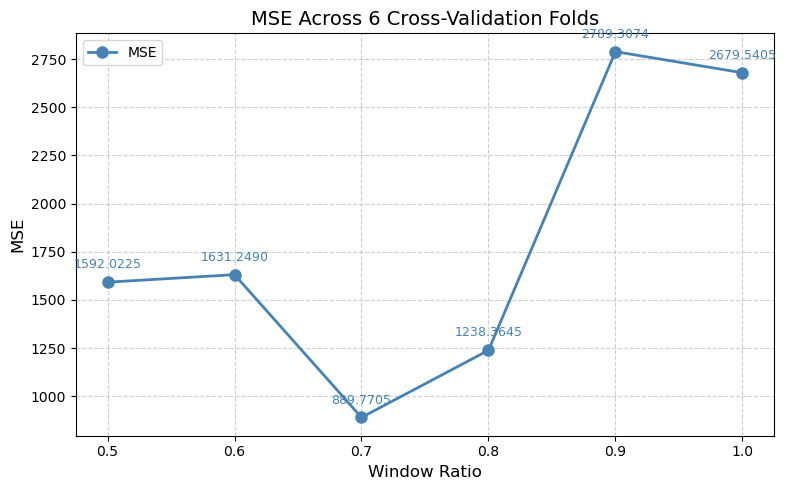

In [29]:
# ── 6. MSE plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(results_df['window_ratio'], results_df['MSE'],
        marker='o', linewidth=2, markersize=8, color='steelblue', label='MSE')
for _, row in results_df.iterrows():
    ax.annotate(f"{row['MSE']:.4f}",
                xy=(row['window_ratio'], row['MSE']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color='steelblue')
ax.set_xlabel('Window Ratio', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_title('MSE Across 6 Cross-Validation Folds', fontsize=14)
ax.set_xticks(split_ratios)
ax.set_xticklabels([str(r) for r in split_ratios])
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.tight_layout()
plt.savefig('mse_cv_folds.png', dpi=150)
plt.show()

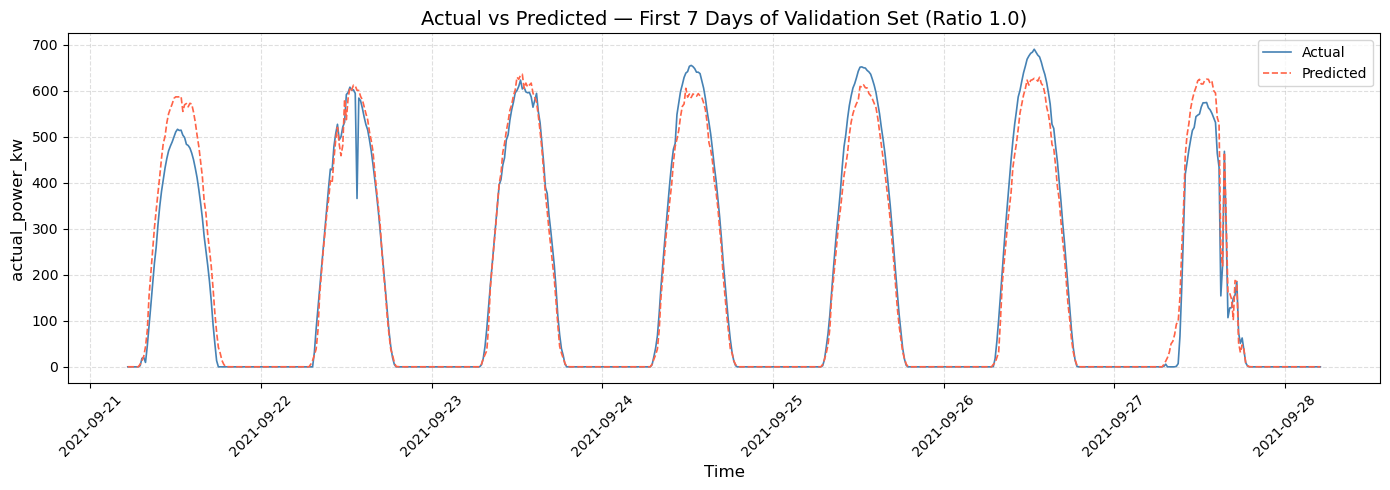

In [30]:
# ── 7. Actual vs Predicted over time (sample 7 days for clarity) ─
sample_n  = 7 * 24 * 4          # 7 days of 15-min intervals
plot_idx  = last_val_idx.iloc[:sample_n]
plot_act  = last_y_val.iloc[:sample_n].values
plot_pred = last_preds[:sample_n]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_idx, plot_act,  label='Actual',    color='steelblue', linewidth=1.2)
ax.plot(plot_idx, plot_pred, label='Predicted', color='tomato',    linewidth=1.2, linestyle='--')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('actual_power_kw', fontsize=12)
ax.set_title('Actual vs Predicted — First 7 Days of Validation Set (Ratio 1.0)', fontsize=14)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('actual_vs_predicted_time.png', dpi=150)
plt.show()

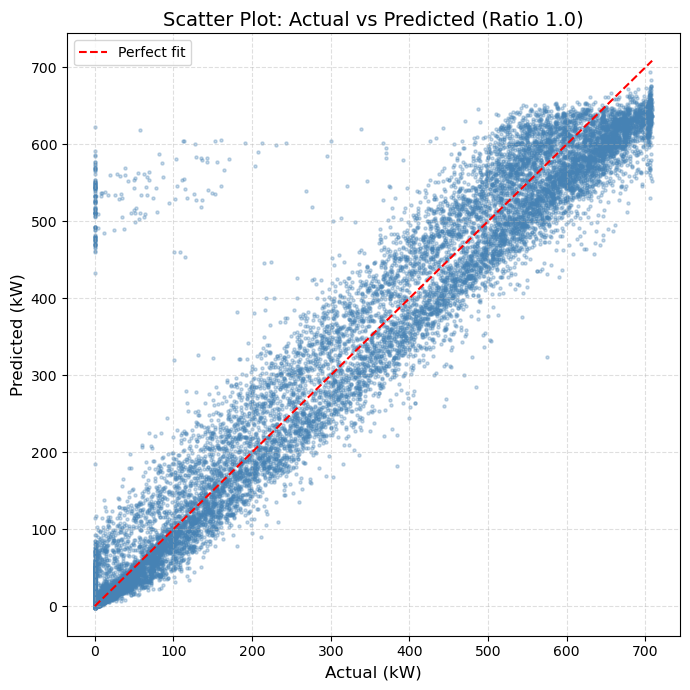

In [31]:
# ── 8. Scatter plot: Actual vs Predicted ────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(last_y_val, last_preds, alpha=0.3, s=5, color='steelblue')
max_val = max(last_y_val.max(), last_preds.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual (kW)', fontsize=12)
ax.set_ylabel('Predicted (kW)', fontsize=12)
ax.set_title('Scatter Plot: Actual vs Predicted (Ratio 1.0)', fontsize=14)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('scatter_actual_vs_predicted.png', dpi=150)
plt.show()

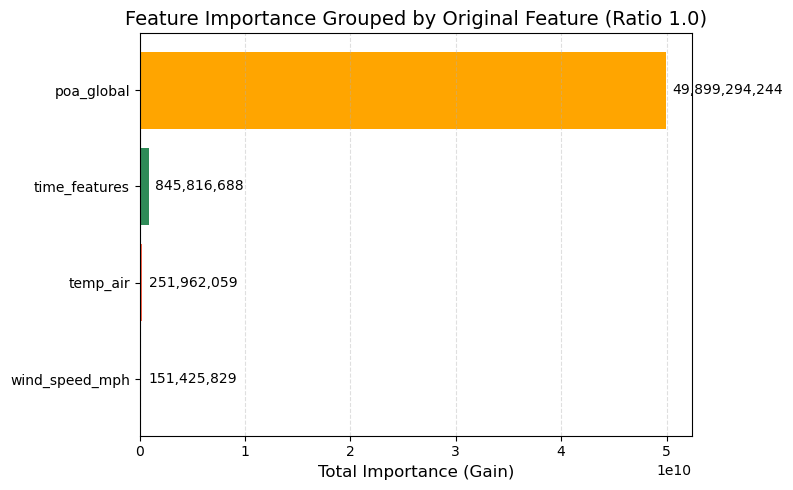

In [32]:
# ── 9. Feature importance grouped by original feature ───────────
importance_df = pd.DataFrame({
    'feature':    last_model.feature_name(),
    'importance': last_model.feature_importance(importance_type='gain'),
})

# Map each engineered feature back to its original
original_features = ['poa_global', 'temp_air', 'wind_speed_mph']

def map_to_original(feature_name):
    for orig in original_features:
        if feature_name.startswith(orig):
            return orig
    return 'time_features'   # catches hour_sin, month_cos, is_daytime etc.

importance_df['original'] = importance_df['feature'].apply(map_to_original)

# Sum importance scores by original feature group
grouped_df = (
    importance_df
    .groupby('original')['importance']
    .sum()
    .reset_index()
    .sort_values('importance', ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue', 'tomato', 'seagreen', 'orange']
ax.barh(grouped_df['original'], grouped_df['importance'],
        color=colors[:len(grouped_df)])
ax.set_xlabel('Total Importance (Gain)', fontsize=12)
ax.set_title('Feature Importance Grouped by Original Feature (Ratio 1.0)', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.4, axis='x')

# Annotate bars with values
for _, row in grouped_df.iterrows():
    ax.annotate(f"{row['importance']:,.0f}",
                xy=(row['importance'], row['original']),
                xytext=(5, 0), textcoords='offset points',
                va='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance_grouped.png', dpi=150)
plt.show()

Now we apply the trained model to do a prediction on the tesing dataset. 

── Test Set Results ──
   MAE: 20.2262
  RMSE: 39.8172
   MSE: 1585.4063


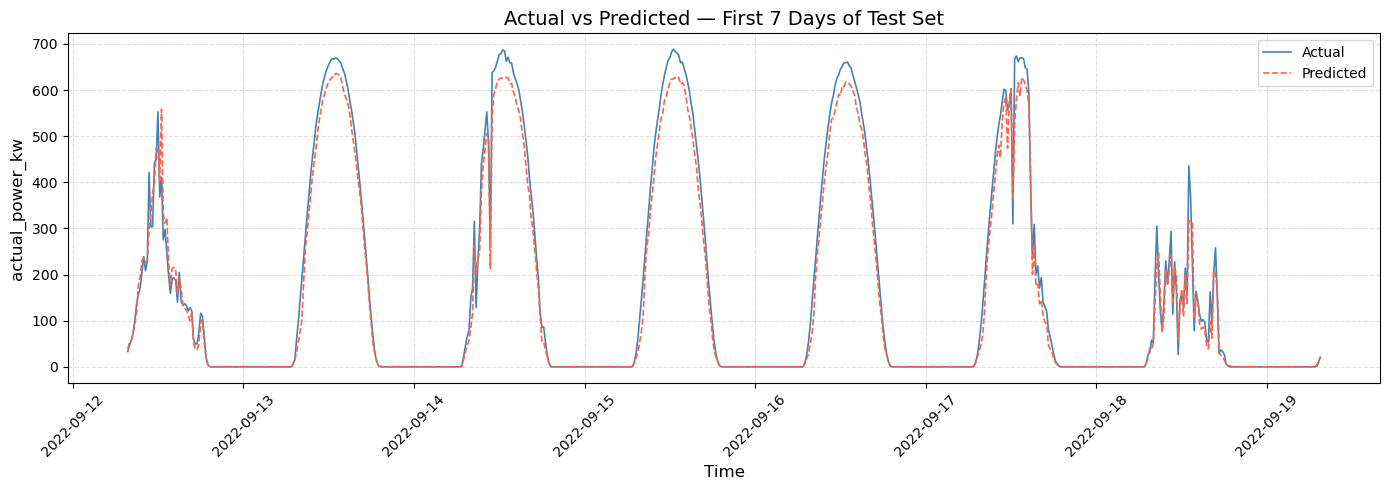

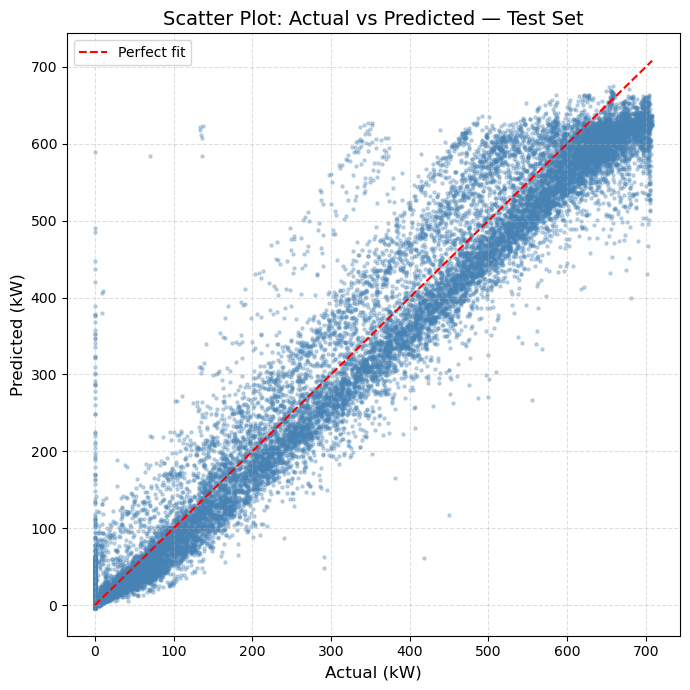

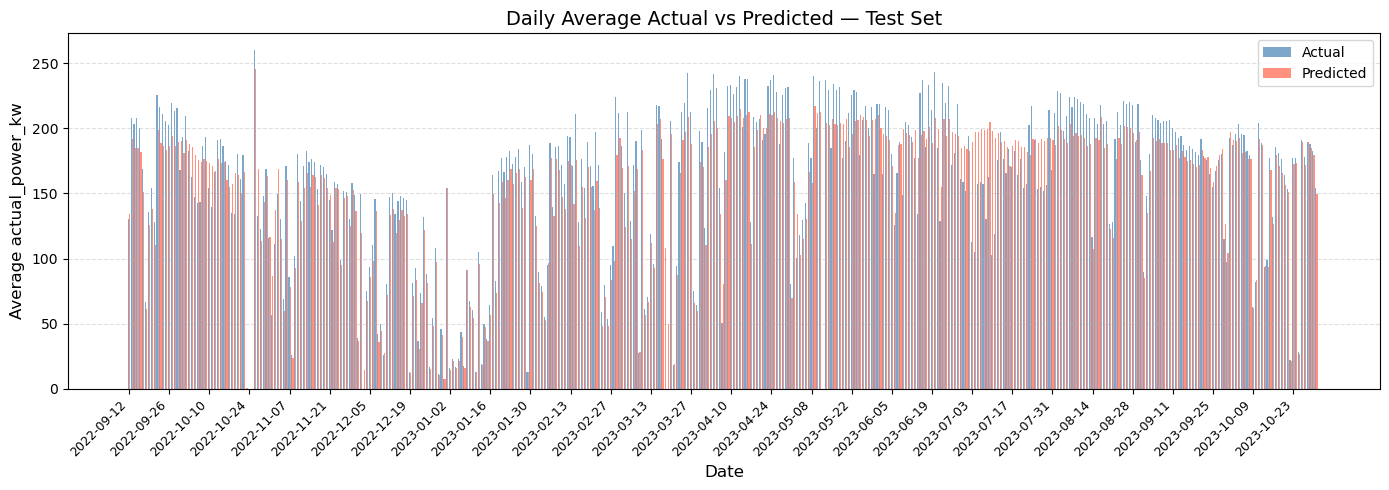

In [33]:
# ── 1. Prepare df_test ──────────────────────────────────────────
df_test_copy = df_test.copy()
df_test_copy['measured_on'] = pd.to_datetime(df_test_copy['measured_on'], utc=True)
df_test_copy = df_test_copy.sort_values('measured_on').reset_index(drop=True)
df_test_copy = df_test_copy.set_index('measured_on')

# ── 2. Apply same feature engineering ──────────────────────────
for col in ['poa_global', 'temp_air', 'wind_speed_mph']:
    df_test_copy[f'{col}_lag1']       = df_test_copy[col].shift(1)
    df_test_copy[f'{col}_lag2']       = df_test_copy[col].shift(2)
    df_test_copy[f'{col}_lag4']       = df_test_copy[col].shift(4)
    df_test_copy[f'{col}_roll4_mean'] = df_test_copy[col].shift(1).rolling(4).mean()
    df_test_copy[f'{col}_roll8_mean'] = df_test_copy[col].shift(1).rolling(8).mean()
    df_test_copy[f'{col}_roll4_std']  = df_test_copy[col].shift(1).rolling(4).std()

df_test_copy['hour_sin']   = np.sin(2 * np.pi * df_test_copy.index.hour / 24)
df_test_copy['hour_cos']   = np.cos(2 * np.pi * df_test_copy.index.hour / 24)
df_test_copy['month_sin']  = np.sin(2 * np.pi * df_test_copy.index.month / 12)
df_test_copy['month_cos']  = np.cos(2 * np.pi * df_test_copy.index.month / 12)
df_test_copy['minute_sin'] = np.sin(2 * np.pi * df_test_copy.index.minute / 60)
df_test_copy['minute_cos'] = np.cos(2 * np.pi * df_test_copy.index.minute / 60)
df_test_copy['is_daytime'] = ((df_test_copy.index.hour >= 6) & 
                               (df_test_copy.index.hour <= 20)).astype(int)

df_test_copy = df_test_copy.dropna().reset_index()

# ── 3. Predict ──────────────────────────────────────────────────
X_test    = df_test_copy[features]
y_test    = df_test_copy[target]
test_preds = last_model.predict(X_test)

# ── 4. Evaluate ─────────────────────────────────────────────────
test_mae  = mean_absolute_error(y_test, test_preds)
test_mse  = mean_squared_error(y_test, test_preds)
test_rmse = test_mse ** 0.5

print("── Test Set Results ──")
print(f"{'MAE':>6}: {test_mae:.4f}")
print(f"{'RMSE':>6}: {test_rmse:.4f}")
print(f"{'MSE':>6}: {test_mse:.4f}")

# ── 5. Actual vs Predicted over time (first 7 days) ─────────────
sample_n      = 7 * 24 * 4
test_idx      = pd.to_datetime(df_test_copy['measured_on'].values)
plot_idx      = test_idx[:sample_n]
plot_act      = y_test.values[:sample_n]
plot_pred     = test_preds[:sample_n]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_idx, plot_act,  label='Actual',    color='steelblue', linewidth=1.2)
ax.plot(plot_idx, plot_pred, label='Predicted', color='tomato',    linewidth=1.2, linestyle='--')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('actual_power_kw', fontsize=12)
ax.set_title('Actual vs Predicted — First 7 Days of Test Set', fontsize=14)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('test_actual_vs_predicted_time.png', dpi=150)
plt.show()

# ── 6. Scatter plot ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, test_preds, alpha=0.3, s=5, color='steelblue')
max_val = max(y_test.max(), test_preds.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual (kW)', fontsize=12)
ax.set_ylabel('Predicted (kW)', fontsize=12)
ax.set_title('Scatter Plot: Actual vs Predicted — Test Set', fontsize=14)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('test_scatter_actual_vs_predicted.png', dpi=150)
plt.show()

# ── 7. Time-based bar chart: Actual vs Predicted ────────────────
df_compare = pd.DataFrame({
    'measured_on': test_idx,
    'Actual':      y_test.values,
    'Predicted':   test_preds
}).set_index('measured_on')

df_daily = df_compare.resample('D').mean()

fig, ax = plt.subplots(figsize=(14, 5))

x     = np.arange(len(df_daily))
width = 0.4

ax.bar(x - width/2, df_daily['Actual'],    width=width, alpha=0.7,
       color='steelblue', label='Actual')
ax.bar(x + width/2, df_daily['Predicted'], width=width, alpha=0.7,
       color='tomato',    label='Predicted')

# Show one label every 2 weeks for clarity
tick_interval = 14
tick_positions = x[::tick_interval]
tick_labels    = df_daily.index[::tick_interval].strftime('%Y-%m-%d')

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Average actual_power_kw', fontsize=12)
ax.set_title('Daily Average Actual vs Predicted — Test Set', fontsize=14)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig('test_histogram_time.png', dpi=150)
plt.show()